### You can run this notebook at Colab by clicking here:

<a target="_blank" href="https://https://colab.research.google.com/github/NMRLipids/databank-template/blob/main/scripts/plotQuality.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Initialize FAIRMD Lipids databank

In [3]:
import os
import sys
import subprocess

# This installs FAIRMD Lipids databank tools on Colab and initializes data.
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "fairmd-lipids"], check=True)
    subprocess.run(["fmdl_initialize_data", "stable"], check=True)

    # Load environment variables from databank_env.rc into this Python process.
    with open("databank_env.rc") as env_file:
        for line in env_file:
            line = line.strip()
            if line.startswith("export ") and "=" in line:
                key, value = line[len("export "):].split("=", 1)
                os.environ[key] = value

# On local machine, set FMDL_DATA_PATH to the initialized databank folder.
# Optionally set FMDL_SIMU_PATH if your simulations are in a non-default location.
# os.environ["FMDL_DATA_PATH"] = "/path/to/your/BilayerData"

In [4]:
# Core FAIRMD Lipids routines and API
from fairmd.lipids.core import initialize_databank
from fairmd.lipids.api import get_mean_ApL, get_thickness, get_eqtimes
from IPython.display import display, Markdown

# Initialize the databank and load all simulations.
systems = initialize_databank()

Simulations are initialized from the folder: /home/hsantila/fairMD_DB/BilayerData/Simulations


# Print and plot basic properties of a system selected based on ID number 

In [5]:
# Define a function - simulation report generator
from plot_tools import plotSimulation
def genReport(ID):
    system = systems.loc(ID)

    # DOI resolver helper in old API was removed; DOI URL is direct.
    doi = system.get("DOI", "")
    url = f"https://doi.org/{doi}" if doi else "N/A"

    # Computed properties via current fairmd.lipids API.
    try:
        APL = get_mean_ApL(system)
    except Exception:
        APL = None
    try:
        thickness = get_thickness(system)
    except Exception:
        thickness = None
    try:
        hydration = system.get_hydration("number")
    except Exception:
        hydration = None

    # Composition using System composition helpers.
    try:
        membrane_comp = system.membrane_composition("molar")
        comp = {k: f"{v * 100:.1f}" for k, v in membrane_comp.items()}
    except Exception:
        comp = {}

    try:
        eq_times = get_eqtimes(system)
        eq_times_str = ", ".join([f"{k}: {v:.2f}" for k, v in eq_times.items()])
    except Exception:
        eq_times_str = "Not available"

    display(Markdown(f'''
## Report for Simulation #{ID}
'''
    ))
    try:
        display(Markdown(f'''
Author(s): _{system['AUTHORS_CONTACT']}_
'''
        ))
    except Exception:
        pass

    date_of_running = system.get("DATEOFRUNNING", "N/A")
    composition_text = f"{':'.join(comp.keys())} ({':'.join(comp.values())})" if comp else "Not available"
    apl_text = f"{APL:.1f} Å$^2$" if APL is not None else "Not available"
    thickness_text = f"{thickness:.1f} nm" if thickness is not None else "Not available"
    hydration_text = f"{hydration:.1f} water/lipid" if hydration is not None else "Not available"

    display(Markdown(f'''
Date: _{date_of_running}_
Simulation permanent link: {url}

- Composition (\%): {composition_text}
- Membrane area per lipid: {apl_text}
- Membrane thickness: {thickness_text}
- Hydration level: {hydration_text}
- Relative equilibration time for each lipid in the simulation (ns): {eq_times_str}
'''
                    ))

    # Plot form factor and C-H bond order parameters with experimental data when available.
    display(Markdown('''
### Graphical report
_Plot form factor and C-H bond order parameters from the simulation_
_together with corresponding experimental data (if available)_
'''))

    for lipid in system.lipids:
        print(lipid)
        plotSimulation(system, lipid)

<>:64: SyntaxWarning: invalid escape sequence '\%'
<>:64: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_12841/193170156.py:64: SyntaxWarning: invalid escape sequence '\%'
  '''



## Report for Simulation #830



Author(s): _Eerika Jokinen, Maisa Vuorte, Matti Javanainen_



Date: _08/04/2025_
Simulation permanent link: https://doi.org/10.5281/zenodo.15172176

- Composition (\%): POPC (100.0)
- Membrane area per lipid: 66.7 Å$^2$
- Membrane thickness: 4.2 nm
- Hydration level: 50.0 water/lipid
- Relative equilibration time for each lipid in the simulation (ns): POPC: 0.28



### Graphical report
_Plot form factor and C-H bond order parameters from the simulation_
_together with corresponding experimental data (if available)_


POPC
DOI: 10.5281/zenodo.15172176
Form factor quality: 0.3048
Using FF scale 77.89 from experiment 10.1021/acs.jctc.3c00648/1.


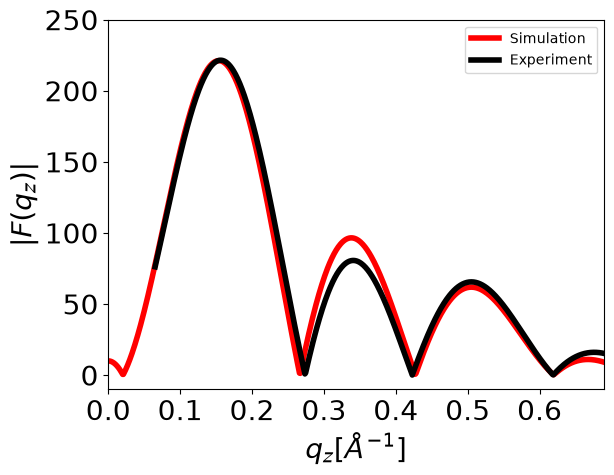

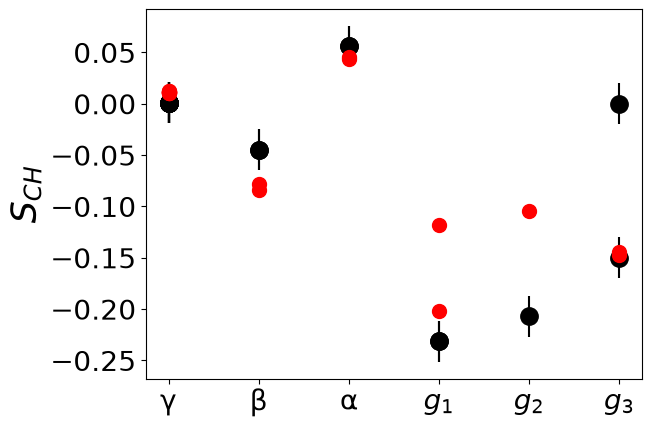

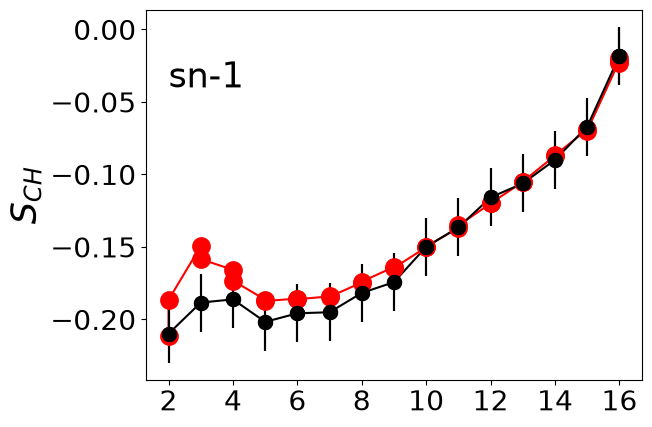

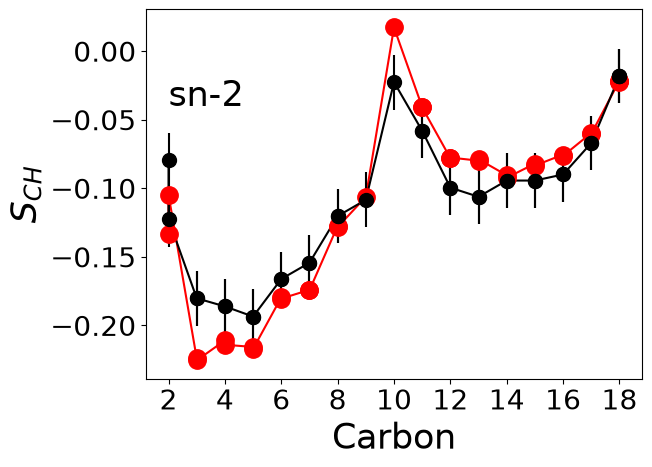

In [6]:
genReport(830)


## Report for Simulation #831



Author(s): _Eerika Jokinen, Maisa Vuorte, Matti Javanainen_



Date: _08/04/2025_
Simulation permanent link: https://doi.org/10.5281/zenodo.15172176

- Composition (\%): POPC (100.0)
- Membrane area per lipid: 64.3 Å$^2$
- Membrane thickness: 4.2 nm
- Hydration level: 50.0 water/lipid
- Relative equilibration time for each lipid in the simulation (ns): POPC: 0.45



### Graphical report
_Plot form factor and C-H bond order parameters from the simulation_
_together with corresponding experimental data (if available)_


POPC
DOI: 10.5281/zenodo.15172176
Form factor quality: 0.2142
Using FF scale 77.09 from experiment 10.1021/acs.jctc.3c00648/1.


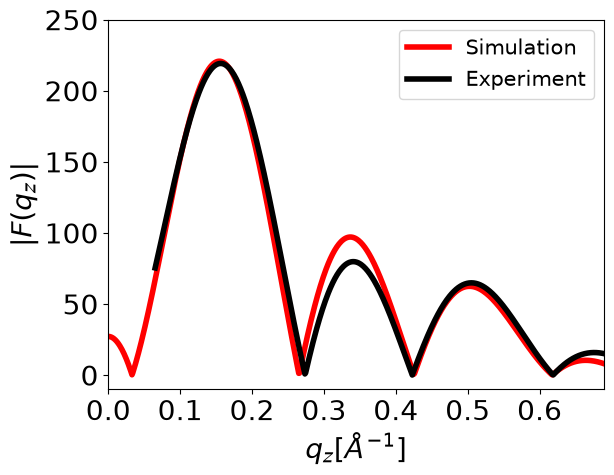

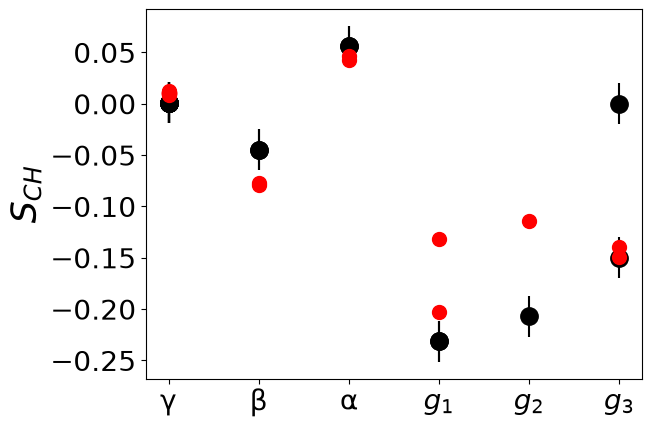

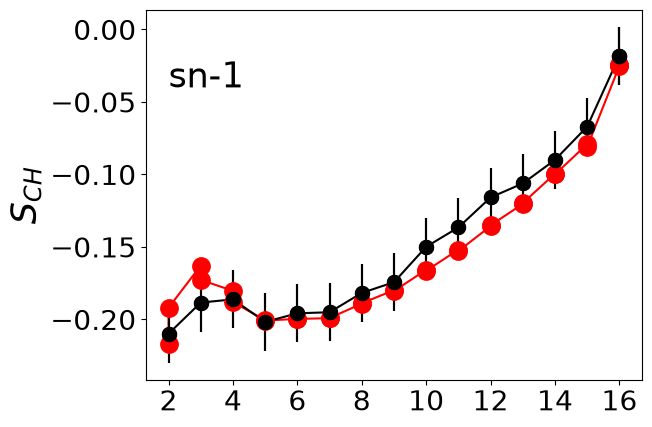

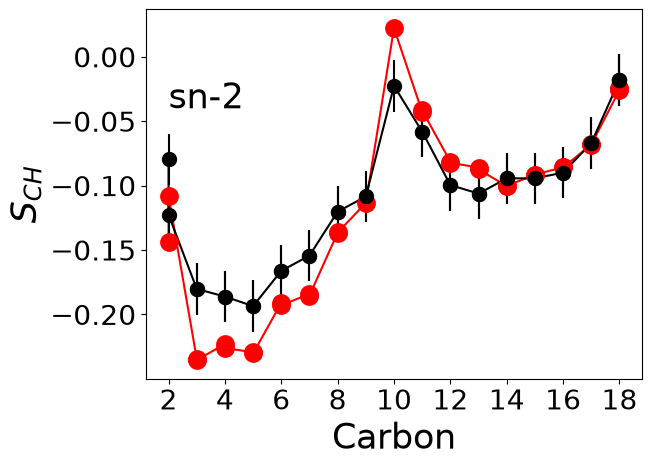

In [7]:
genReport(831)


## Report for Simulation #376



Author(s): _Antila, Hanne_



Date: _12/10/2021_
Simulation permanent link: https://doi.org/10.5281/zenodo.4352287

- Composition (\%): POPC (100.0)
- Membrane area per lipid: 67.2 Å$^2$
- Membrane thickness: 4.0 nm
- Hydration level: 40.0 water/lipid
- Relative equilibration time for each lipid in the simulation (ns): POPC: 0.10



### Graphical report
_Plot form factor and C-H bond order parameters from the simulation_
_together with corresponding experimental data (if available)_


POPC
DOI: 10.5281/zenodo.4352287
Form factor quality: 0.9971
Using FF scale 101.9 from experiment 10.1016/j.bbamem.2011.07.022/2.


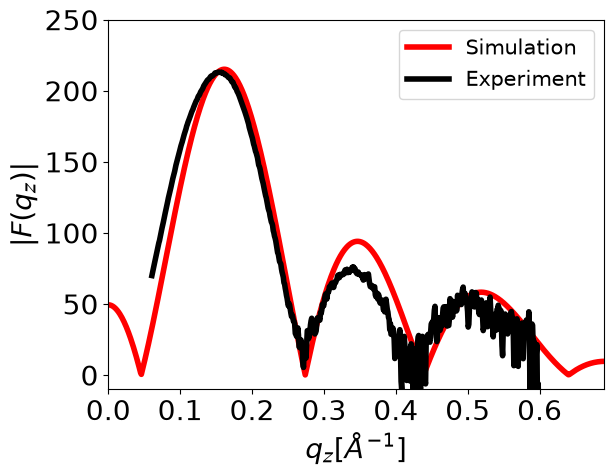

No matched OP experiment data found for POPC.


In [8]:
genReport(376)